In [1]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path


In [2]:
path_OI = '../data/'
path_output = '../figures/'

In [3]:
ds_duacs = xr.open_dataset(path_OI + 'mean_dynamic_DUACS_10_years.nc')
ds_duacs = ds_duacs.sel(latitude = slice(-65, 65))
LON2D, LAT2D = np.meshgrid(ds_duacs.longitude, ds_duacs.latitude)
mask_KE = np.ma.masked_where(abs(LAT2D)<3, ds_duacs.SKE.values) # mask the equator

In [4]:
############
# --- Area of Interrest
############

poly_lon = np.array([-69, -73, -77, -77, -53, -53, -69])+360
poly_lat = [41, 35, 32, 32, 32, 41, 41]

poly_lon_ccs = np.array([-131, -131, -126, -120, -131])+360
poly_lat_ccs = [32, 42, 42, 32, 32]


poly_lon_agulhas = [10, 17, 18, 27, 37, 37, 10, 10]
poly_lat_agulhas = [-30, -30, -35, -35, -27, -43, -43, -30]


poly_lon_acc1 = [78, 78, 102, 102, 78]
poly_lat_acc1 = [-56, -45, -45, -56, -56]


poly_lon_acc2 = [-55, -55, -31, -31, -55]
poly_lat_acc2 = [-63, -52, -52, -63, -63]


poly_lon_med = [.1, .1, 16.8, 16.8, .1]
poly_lat_med = [33.2, 44, 44, 33.2, 33.2]

In [5]:

ds_GS = xr.open_dataset(path_OI + 'GS_snapshot.nc') # snapshot region GS
ds_CCS = xr.open_dataset(path_OI + 'CCS_snapshot.nc') # snapshot region CCS
ds_AGULHAS = xr.open_dataset(path_OI + 'AGULHAS_snapshot.nc') # snapshot region AGULHAS
ds_ACC1 = xr.open_dataset(path_OI + 'ACC1_snapshot.nc') # snapshot region ACC1
ds_ACC2 = xr.open_dataset(path_OI + 'ACC2_snapshot.nc') # snapshot region ACC2
ds_MED = xr.open_dataset(path_OI + 'MED_snapshot.nc') # snapshot region MED
ds_swath = xr.open_dataset(path_OI + 'swath_swot.nc') # a dummy dataset for the SWOT swath location




In [6]:

LON2d_GS, LAT2d_GS = np.meshgrid(ds_GS.longitude, ds_GS.latitude)
masked_LON2d_GS2 = np.ma.masked_where(np.isnan(ds_GS.uspeed.squeeze()), LON2d_GS)
masked_LAT2d_GS2 = np.ma.masked_where(np.isnan(ds_GS.uspeed.squeeze()), LAT2d_GS)
masked_LON2d_GS = masked_LON2d_GS2[280:, :]
masked_LAT2d_GS = masked_LAT2d_GS2[280:, :]

LON2d_CCS, LAT2d_CCS = np.meshgrid(ds_CCS.longitude, ds_CCS.latitude)
masked_LON2d_CSS = np.ma.masked_where(np.isnan(ds_CCS.uspeed.squeeze()), LON2d_CCS)
masked_LAT2d_CSS = np.ma.masked_where(np.isnan(ds_CCS.uspeed.squeeze()), LAT2d_CCS)


LON2d_AGULHAS, LAT2d_AGULHAS = np.meshgrid(ds_AGULHAS.longitude, ds_AGULHAS.latitude)
masked_LON2d_AGULHAS = np.ma.masked_where(np.isnan(ds_AGULHAS.uspeed.squeeze()), LON2d_AGULHAS)
masked_LAT2d_AGULHAS = np.ma.masked_where(np.isnan(ds_AGULHAS.uspeed.squeeze()), LAT2d_AGULHAS)


LON2d_ACC1, LAT2d_ACC1 = np.meshgrid(ds_ACC1.longitude, ds_ACC1.latitude)
masked_LON2d_ACC1 = np.ma.masked_where(np.isnan(ds_ACC1.uspeed.squeeze()), LON2d_ACC1)
masked_LAT2d_ACC1 = np.ma.masked_where(np.isnan(ds_ACC1.uspeed.squeeze()), LAT2d_ACC1)


LON2d_ACC2, LAT2d_ACC2 = np.meshgrid(ds_ACC2.longitude, ds_ACC2.latitude)
masked_LON2d_ACC2 = np.ma.masked_where(np.isnan(ds_ACC2.uspeed.squeeze()), LON2d_ACC2)
masked_LAT2d_ACC2 = np.ma.masked_where(np.isnan(ds_ACC2.uspeed.squeeze()), LAT2d_ACC2)


LON2d_MED, LAT2d_MED = np.meshgrid(ds_MED.longitude, ds_MED.latitude)
masked_LON2d_MED = np.ma.masked_where(np.isnan(ds_MED.uspeed_oi.squeeze()), LON2d_MED)
masked_LAT2d_MED = np.ma.masked_where(np.isnan(ds_MED.uspeed_oi.squeeze()), LAT2d_MED)

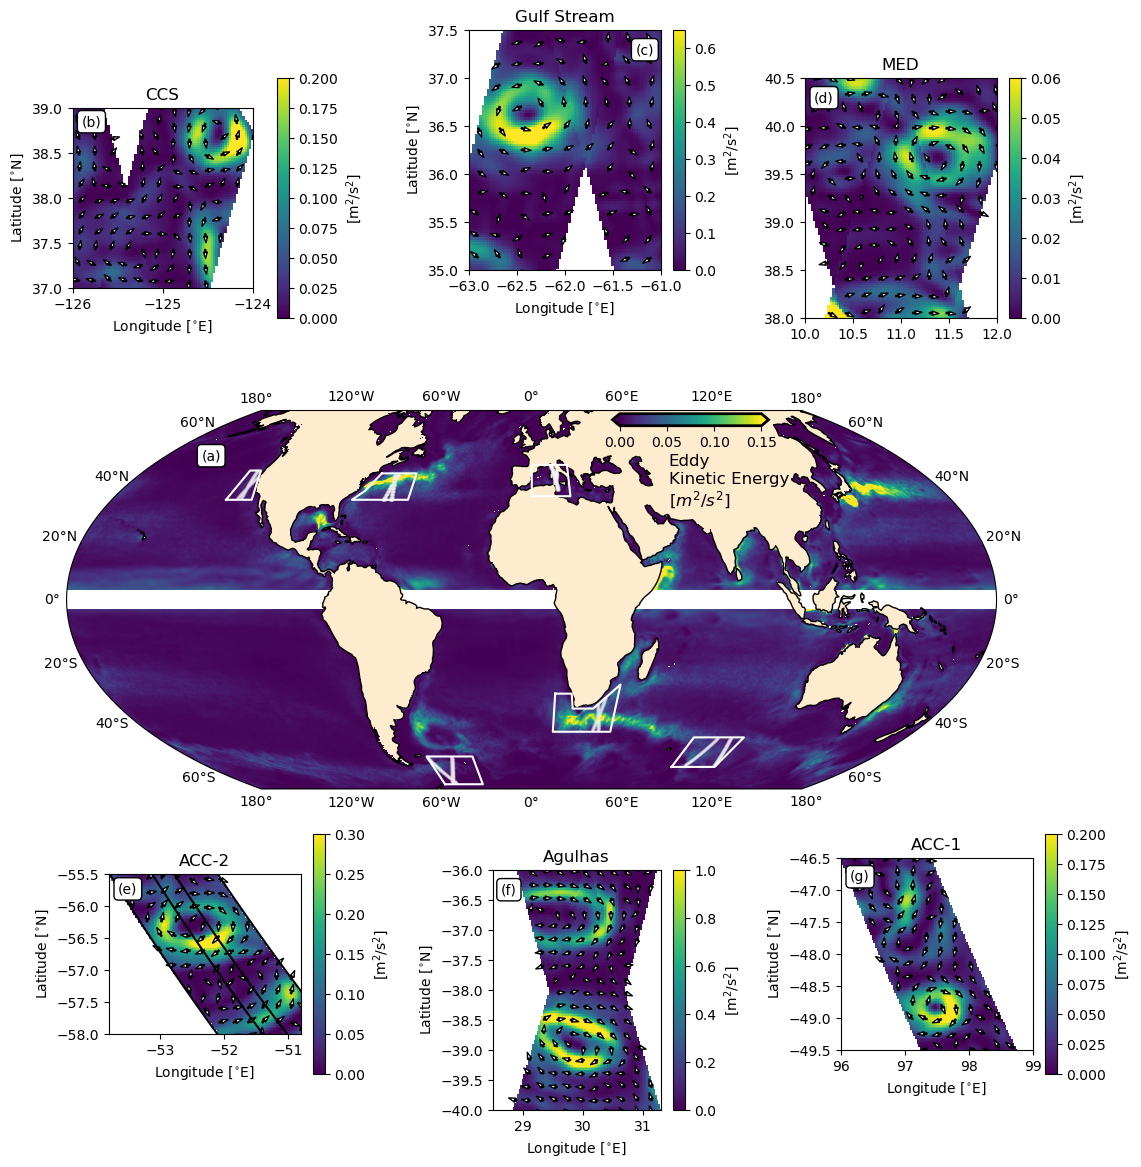

In [7]:
props = dict(boxstyle='round', facecolor='w')


subplot_kw = {'projection': ccrs.Mollweide( central_longitude=0, globe=None)}
fig, ax = plt.subplots(subplot_kw=subplot_kw, figsize = (12, 12))

ax.add_feature(cfeature.LAND, color='blanchedalmond')
ax.coastlines()
gl = ax.gridlines(
    draw_labels=True,
    dms=False,
    x_inline=False,
    y_inline=False,
    linestyle='--',
    lw=0,
)

for ea in gl.ylabel_artists:
    right_label = ea.get_position()[0] > 0
    # print(ea, ea.get_position()[0], ea.get_visible())
    if right_label:
        ea.set_visible(False)


ax.text(0.145, 0.87, '(a)',
     transform = ax.transAxes, bbox = props)

p1 = ax.pcolormesh(ds_duacs.longitude[::1].values, ds_duacs.latitude[::1].values, mask_KE[::1, ::1], vmin = 0 , vmax = .15, transform = ccrs.PlateCarree(), cmap = 'viridis', shading='nearest',)

lon = np.ma.filled(masked_LON2d_GS, np.nan)[::20, ::1]
lat = np.ma.filled(masked_LAT2d_GS, np.nan)[::20, ::1]

m = np.isfinite(lon) & np.isfinite(lat)
ax.scatter(lon[m], lat[m], s=1, alpha=0.05, color="w",
           transform=ccrs.PlateCarree(), zorder=2)



ax.plot(poly_lon, poly_lat, transform = ccrs.PlateCarree(), label = 'GS', color = 'w', zorder = 10)
ax.plot(poly_lon_ccs, poly_lat_ccs, transform = ccrs.PlateCarree(), label = 'CCS', color = 'w', zorder = 10)
ax.plot(poly_lon_agulhas, poly_lat_agulhas, transform = ccrs.PlateCarree(), label = 'AGU', color = 'w', zorder = 10)


ax.plot(poly_lon_acc1, poly_lat_acc1, transform = ccrs.PlateCarree(), label = 'ACC1', color = 'w', zorder = 10)
ax.plot(poly_lon_acc2, poly_lat_acc2, transform = ccrs.PlateCarree(), label = 'ACC2', color = 'w', zorder = 10)
ax.plot(poly_lon_med, poly_lat_med, transform = ccrs.PlateCarree(), label = 'MED', color = 'w', zorder = 10)




ax_inset_GS = fig.add_axes([.46, .77, .2, .2])

ax_inset_GS.text(0.87, 0.9, '(c)',
     transform = ax_inset_GS.transAxes, bbox = props)



p_GS = ax_inset_GS.pcolormesh(ds_GS.longitude-360, ds_GS.latitude, 1/2*(ds_GS.ugos.squeeze()**2 + ds_GS.vgos.squeeze()**2), vmin = 0, vmax = .65)
plt.colorbar(p_GS, label = '[m$^{2}$/s$^{2}$]')

nb_quiver = 9
LON2d, LAT2d = np.meshgrid(ds_GS.longitude.values-360, ds_GS.latitude.values)
ax_inset_GS.quiver(LON2d[::nb_quiver, ::nb_quiver], LAT2d[::nb_quiver, ::nb_quiver], np.squeeze(ds_GS.ugos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_GS.uspeed)[::nb_quiver, ::nb_quiver], np.squeeze(ds_GS.vgos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_GS.uspeed)[::nb_quiver, ::nb_quiver], \
          scale = 20, width = 0.007, facecolor = 'w', edgecolor = 'k', linewidth = 1)
ax_inset_GS.set_xlim([-63, -61])
ax_inset_GS.set_ylim([35, 37.5])
ax_inset_GS.set_xlabel('Longitude [$^{\circ}$E]')
ax_inset_GS.set_ylabel('Latitude [$^{\circ}$N]')
ax_inset_GS.set_title('Gulf Stream')

ax_inset_GS.set_aspect('equal', 'box')

ax_inset_CCS = fig.add_axes([.13, .73, .2, .2])
ax_inset_CCS.text(0.05, 0.9, '(b)',
     transform = ax_inset_CCS.transAxes, bbox = props)



p_CCS = ax_inset_CCS.pcolormesh(ds_CCS.longitude-360, ds_CCS.latitude, 1/2*(ds_CCS.ugos.squeeze()**2 + ds_CCS.vgos.squeeze()**2), vmin = 0, vmax = .2)
plt.colorbar(p_CCS, label = '[m$^{2}$/s$^{2}$]', pad=0.1)

ax.plot(masked_LON2d_CSS[::20, ::1], masked_LAT2d_CSS[::20, ::1], alpha = .05, color = 'w', transform = ccrs.PlateCarree(), zorder = 2) # tr

nb_quiver = 7
LON2d, LAT2d = np.meshgrid(ds_CCS.longitude.values-360, ds_CCS.latitude.values)
ax_inset_CCS.quiver(LON2d[::nb_quiver, ::nb_quiver], LAT2d[::nb_quiver, ::nb_quiver], np.squeeze(ds_CCS.ugos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_CCS.uspeed)[::nb_quiver, ::nb_quiver], \
                    np.squeeze(ds_CCS.vgos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_CCS.uspeed)[::nb_quiver, ::nb_quiver], \
          scale = 20, width = 0.007, facecolor = 'w', edgecolor = 'k', linewidth = 1)
ax_inset_CCS.set_xlim([-126, -124])
ax_inset_CCS.set_ylim([37, 39])
ax_inset_CCS.set_xticks([-126, -124, -125])
ax_inset_CCS.set_title('CCS')


ax_inset_CCS.set_xlabel('Longitude [$^{\circ}$E]')
ax_inset_CCS.set_ylabel('Latitude [$^{\circ}$N]')

ax_inset_CCS.set_aspect('equal', 'box')

ax_inset_MED = fig.add_axes([.74, .73, .2, .2])
pMED = ax_inset_MED.pcolormesh(ds_MED.longitude, ds_MED.latitude, 1/2*(ds_MED.ugos_oi.squeeze()**2 + ds_MED.vgos_oi.squeeze()**2), vmin = 0.0, vmax = .06)


plt.colorbar(pMED, label = '[m$^{2}$/s$^{2}$]')
ax.plot(masked_LON2d_MED[::2, ::1], masked_LAT2d_MED[::2, ::1], alpha = .1, color = 'w', transform = ccrs.PlateCarree(), zorder = 2) # tr

# nb_quiver = 9
LON2d, LAT2d = np.meshgrid(ds_MED.longitude.values, ds_MED.latitude.values)
ax_inset_MED.quiver(LON2d[::nb_quiver, ::nb_quiver], LAT2d[::nb_quiver, ::nb_quiver], np.squeeze(ds_MED.ugos_oi)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_MED.uspeed_oi)[::nb_quiver, ::nb_quiver], \
                    np.squeeze(ds_MED.vgos_oi)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_MED.uspeed_oi)[::nb_quiver, ::nb_quiver], \
          scale = 20, width = 0.007, facecolor = 'w', edgecolor = 'k', linewidth = 1)

ax_inset_MED.text(0.05, 0.9, '(d)',
     transform = ax_inset_MED.transAxes, bbox = props)

ax_inset_MED.set_title('MED')


ax_inset_MED.set_xlim([10, 12])
ax_inset_MED.set_ylim([38, 40.5])

ax_inset_MED.set_aspect('equal', 'box')

ax_inset_AGULHAS = fig.add_axes([.46, .07, .2, .2])

p_AGULHAS = ax_inset_AGULHAS.pcolormesh(ds_AGULHAS.longitude, ds_AGULHAS.latitude, 1/2*(ds_AGULHAS.ugos.squeeze()**2+ds_AGULHAS.vgos.squeeze()**2), vmin = 0, vmax = 1)
plt.colorbar(p_AGULHAS, label = '[m$^{2}$/s$^{2}$]')

ax.plot(masked_LON2d_AGULHAS[::20, ::1], masked_LAT2d_AGULHAS[::20, ::1], alpha = .05, color = 'w', transform = ccrs.PlateCarree(), zorder = 2) # tr

nb_quiver = 9
LON2d, LAT2d = np.meshgrid(ds_AGULHAS.longitude.values, ds_AGULHAS.latitude.values)
ax_inset_AGULHAS.quiver(LON2d[::nb_quiver, ::nb_quiver], LAT2d[::nb_quiver, ::nb_quiver], np.squeeze(ds_AGULHAS.ugos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_AGULHAS.uspeed)[::nb_quiver, ::nb_quiver], \
                    np.squeeze(ds_AGULHAS.vgos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_AGULHAS.uspeed)[::nb_quiver, ::nb_quiver], \
          scale = 20, width = 0.008, facecolor = 'w', edgecolor = 'k', linewidth = 1)
ax_inset_AGULHAS.set_xlim([28.5, 31.3])
ax_inset_AGULHAS.set_ylim([-40, -36])
ax_inset_AGULHAS.set_xlabel('Longitude [$^{\circ}$E]')
ax_inset_AGULHAS.set_ylabel('Latitude [$^{\circ}$N]')
ax_inset_AGULHAS.set_title('Agulhas')
ax_inset_AGULHAS.set_aspect('equal', 'box')
ax_inset_AGULHAS.text(0.05, 0.9, '(f)',
     transform = ax_inset_AGULHAS.transAxes, bbox = props)




ax_inset_ACC2 = fig.add_axes([.16, .1, .2, .2])

pACC2 = ax_inset_ACC2.pcolormesh(ds_ACC2.longitude-360, ds_ACC2.latitude, 1/2*(ds_ACC2.ugos.squeeze()**2+ds_ACC2.vgos.squeeze()**2), vmin = 0, vmax = .3)
ax.plot(masked_LON2d_ACC2[::20, ::1], masked_LAT2d_ACC2[::20, ::1], alpha = .05, color = 'w', transform = ccrs.PlateCarree(), zorder = 2) # tr
plt.colorbar(pACC2, label = '[m$^{2}$/s$^{2}$]')

nb_quiver = 9
LON2d, LAT2d = np.meshgrid(ds_ACC2.longitude.values-360, ds_ACC2.latitude.values)
ax_inset_ACC2.quiver(LON2d[::nb_quiver, ::nb_quiver], LAT2d[::nb_quiver, ::nb_quiver], np.squeeze(ds_ACC2.ugos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_ACC2.uspeed)[::nb_quiver, ::nb_quiver], \
                    np.squeeze(ds_ACC2.vgos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_ACC2.uspeed)[::nb_quiver, ::nb_quiver], \
          scale = 20, width = 0.007, facecolor = 'w', edgecolor = 'k', linewidth = 1)
ax_inset_ACC2.set_xlim([-53.8, -50.8])
ax_inset_ACC2.set_ylim([-58, -55.5])
ax_inset_ACC2.plot(ds_swath.longitude[:, 5]-360, ds_swath.latitude[:, 5], color = 'k')
ax_inset_ACC2.plot(ds_swath.longitude[:, -14]-360, ds_swath.latitude[:, -14], color = 'k')
ax_inset_ACC2.plot(ds_swath.longitude[:, 25]-360, ds_swath.latitude[:, 25], color = 'k')
ax_inset_ACC2.plot(ds_swath.longitude[:, -34]-360, ds_swath.latitude[:, 38], color = 'k')

ax_inset_ACC2.set_xlabel('Longitude [$^{\circ}$E]')
ax_inset_ACC2.set_ylabel('Latitude [$^{\circ}$N]')
ax_inset_ACC2.set_aspect('equal', 'box')
ax_inset_ACC2.set_title('ACC-2')

ax_inset_ACC2.text(0.05, 0.88, '(e)',
     transform = ax_inset_ACC2.transAxes, bbox = props)


ax_inset_ACC1 = fig.add_axes([.77, .1, .2, .2])

pACC1 = ax_inset_ACC1.pcolormesh(ds_ACC1.longitude, ds_ACC1.latitude, 1/2*(ds_ACC1.ugos.squeeze()**2+ds_ACC1.vgos.squeeze()**2), vmin = 0, vmax = .2)



plt.colorbar(pACC1, label = '[m$^{2}$/s$^{2}$]')
ax.plot(masked_LON2d_ACC1[::20, ::1], masked_LAT2d_ACC1[::20, ::1], alpha = .05, color = 'w', transform = ccrs.PlateCarree(), zorder = 2) # tr

nb_quiver = 9
LON2d, LAT2d = np.meshgrid(ds_ACC1.longitude.values, ds_ACC1.latitude.values)
ax_inset_ACC1.quiver(LON2d[::nb_quiver, ::nb_quiver], LAT2d[::nb_quiver, ::nb_quiver], np.squeeze(ds_ACC1.ugos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_ACC1.uspeed)[::nb_quiver, ::nb_quiver], \
                    np.squeeze(ds_ACC1.vgos)[::nb_quiver, ::nb_quiver]/np.squeeze(ds_ACC1.uspeed)[::nb_quiver, ::nb_quiver], \
          scale = 20, width = 0.007, facecolor = 'w', edgecolor = 'k', linewidth = 1)


ax_inset_ACC1.set_xlim([96, 99])
ax_inset_ACC1.set_ylim([-49.5, -46.5])


ax_inset_ACC1.set_xlabel('Longitude [$^{\circ}$E]')
ax_inset_ACC1.set_ylabel('Latitude [$^{\circ}$N]')
ax_inset_ACC1.set_title('ACC-1')
ax_inset_ACC1.set_aspect('equal', 'box')
ax_inset_ACC1.text(0.05, 0.88, '(g)',
     transform = ax_inset_ACC1.transAxes, bbox = props)

cax = fig.add_axes([.58, .64, .13, 0.01])
cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', extend = 'both', pad = 10)
ax.text(58, 30, 'Eddy\nKinetic Energy\n[$m^{2}/s^{2}$]', transform = ccrs.PlateCarree(), fontsize = 12)
cbar.outline.set_linewidth(2)

plt.savefig(path_output + 'Fig1.png', dpi = 300, bbox_inches = 'tight')
